In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

%matplotlib inline

torch.manual_seed(42)
np.random.seed(42)

In [2]:
device = (
    'cuda' if torch.cuda.is_available() else
    'mps' if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available() else
    'cpu'
)
print('device:', device)

device: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform,
)

print('train size:', len(train_dataset))
print('test size :', len(test_dataset))

train size: 60000
test size : 10000


image shape: torch.Size([1, 28, 28])
label: 5


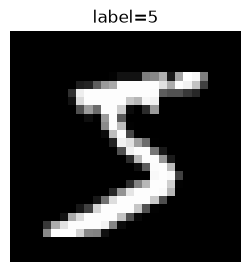

In [4]:
raw_img, raw_label = train_dataset[0]
print('image shape:', raw_img.shape)
print('label:', raw_label)

vis_img = raw_img.squeeze().numpy() * 0.3081 + 0.1307
plt.figure(figsize=(3, 3))
plt.imshow(vis_img, cmap='gray')
plt.title(f'label={raw_label}')
plt.axis('off')
plt.show()

In [5]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

X_batch, y_batch = next(iter(train_loader))
print('batch image shape:', X_batch.shape)
print('batch label shape:', y_batch.shape)

batch image shape: torch.Size([128, 1, 28, 28])
batch label shape: torch.Size([128])


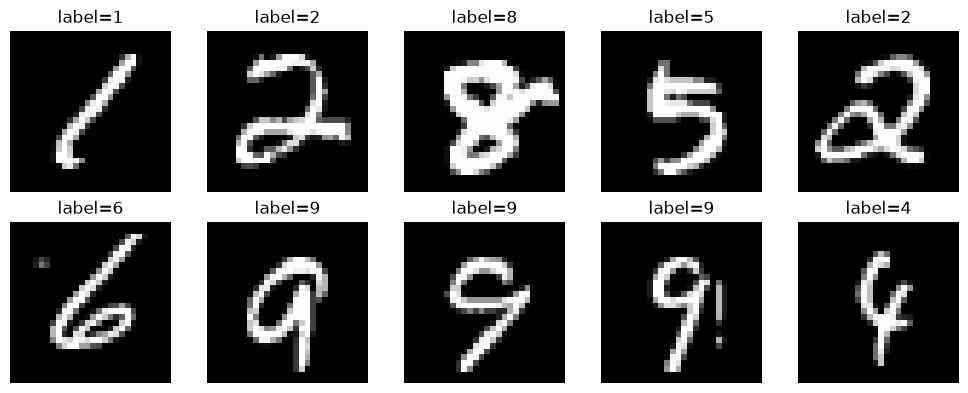

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, img, label in zip(axes.ravel(), X_batch[:10], y_batch[:10]):
    ax.imshow((img.squeeze().numpy() * 0.3081 + 0.1307), cmap='gray')
    ax.set_title(f'label={label.item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [7]:
class MNISTCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = MNISTCNN().to(device)
print(model)

MNISTCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [8]:
with torch.no_grad():
    x = torch.randn(4, 1, 28, 28).to(device)
    print('input     :', x.shape)
    x = model.features[0](x)
    print('conv1     :', x.shape)
    x = model.features[1](x)
    print('relu1     :', x.shape)
    x = model.features[2](x)
    print('pool1     :', x.shape)
    x = model.features[3](x)
    print('conv2     :', x.shape)
    x = model.features[4](x)
    print('relu2     :', x.shape)
    x = model.features[5](x)
    print('pool2     :', x.shape)

input     : torch.Size([4, 1, 28, 28])
conv1     : torch.Size([4, 16, 28, 28])
relu1     : torch.Size([4, 16, 28, 28])
pool1     : torch.Size([4, 16, 14, 14])
conv2     : torch.Size([4, 32, 14, 14])
relu2     : torch.Size([4, 32, 14, 14])
pool2     : torch.Size([4, 32, 7, 7])


In [9]:
learning_rate = 1e-3
epochs = 5

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)

            total_loss += loss.item() * X.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / total, correct / total

In [11]:
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
    )

Epoch 01 | train_loss=0.2516 train_acc=0.9245 | test_loss=0.0607 test_acc=0.9794
Epoch 02 | train_loss=0.0723 train_acc=0.9774 | test_loss=0.0397 test_acc=0.9870
Epoch 03 | train_loss=0.0525 train_acc=0.9836 | test_loss=0.0348 test_acc=0.9882
Epoch 04 | train_loss=0.0416 train_acc=0.9866 | test_loss=0.0313 test_acc=0.9898
Epoch 05 | train_loss=0.0357 train_acc=0.9887 | test_loss=0.0304 test_acc=0.9894


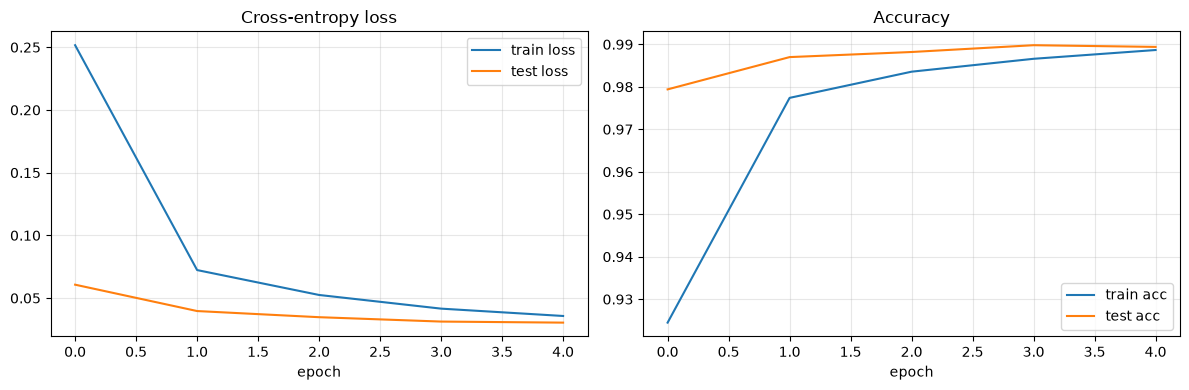

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='train loss')
axes[0].plot(history['test_loss'], label='test loss')
axes[0].set_title('Cross-entropy loss')
axes[0].set_xlabel('epoch')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(history['train_acc'], label='train acc')
axes[1].plot(history['test_acc'], label='test acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('epoch')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

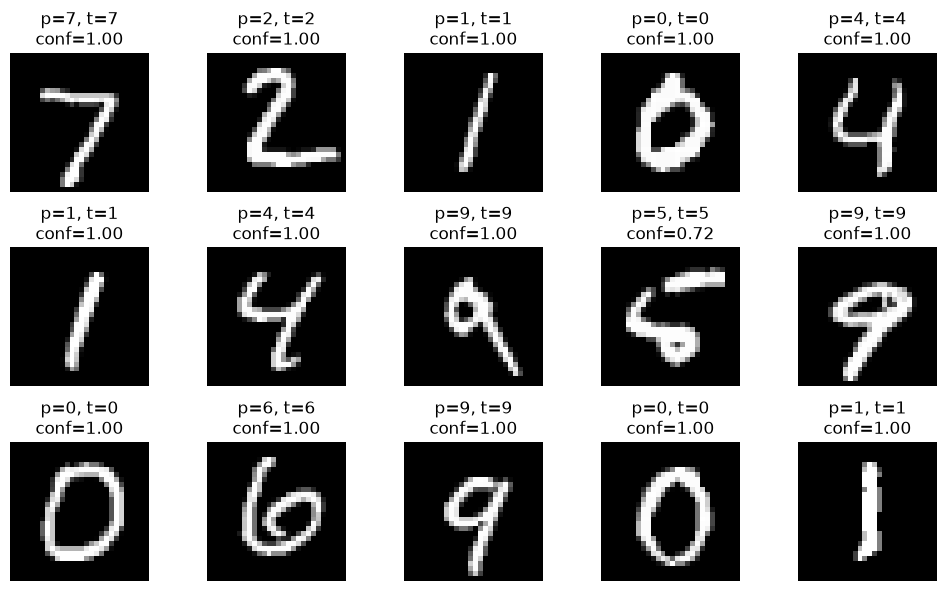

In [13]:
model.eval()
X_vis, y_vis = next(iter(test_loader))
X_vis_device = X_vis.to(device)

with torch.no_grad():
    logits = model(X_vis_device)
    probs = torch.softmax(logits, dim=1)
    preds = logits.argmax(dim=1).cpu()
    confs = probs.max(dim=1).values.cpu()

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for ax, img, pred, true, conf in zip(axes.ravel(), X_vis[:15], preds[:15], y_vis[:15], confs[:15]):
    vis = img.squeeze().numpy() * 0.3081 + 0.1307
    ax.imshow(vis, cmap='gray')
    ax.set_title(f'p={pred.item()}, t={true.item()}\nconf={conf.item():.2f}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [14]:
all_preds = []
all_true = []

model.eval()
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

cm = confusion_matrix(all_true, all_preds)
print(classification_report(all_true, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9889    0.9990    0.9939       980
           1     0.9913    0.9991    0.9952      1135
           2     0.9922    0.9855    0.9888      1032
           3     0.9891    0.9901    0.9896      1010
           4     0.9939    0.9898    0.9918       982
           5     0.9854    0.9843    0.9849       892
           6     0.9896    0.9906    0.9901       958
           7     0.9855    0.9903    0.9879      1028
           8     0.9907    0.9846    0.9876       974
           9     0.9870    0.9792    0.9831      1009

    accuracy                         0.9894     10000
   macro avg     0.9894    0.9892    0.9893     10000
weighted avg     0.9894    0.9894    0.9894     10000



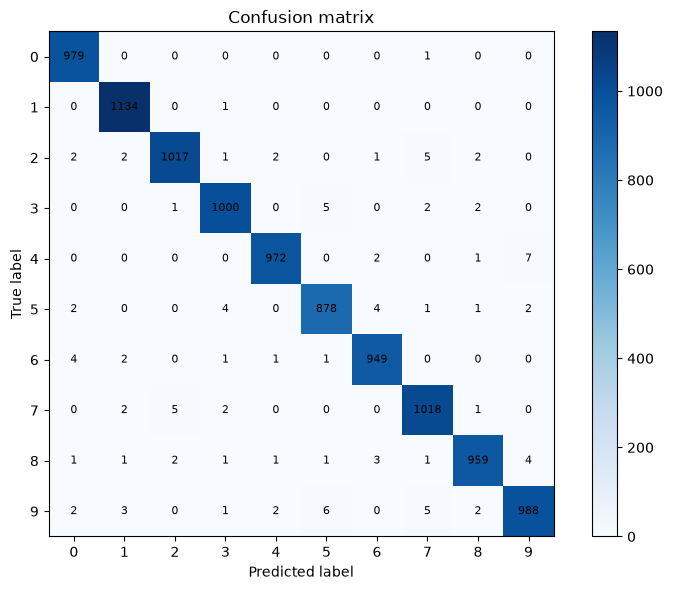

In [15]:
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks(range(10))
plt.yticks(range(10))

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=8)

plt.colorbar()
plt.tight_layout()
plt.show()

total mistakes: 106


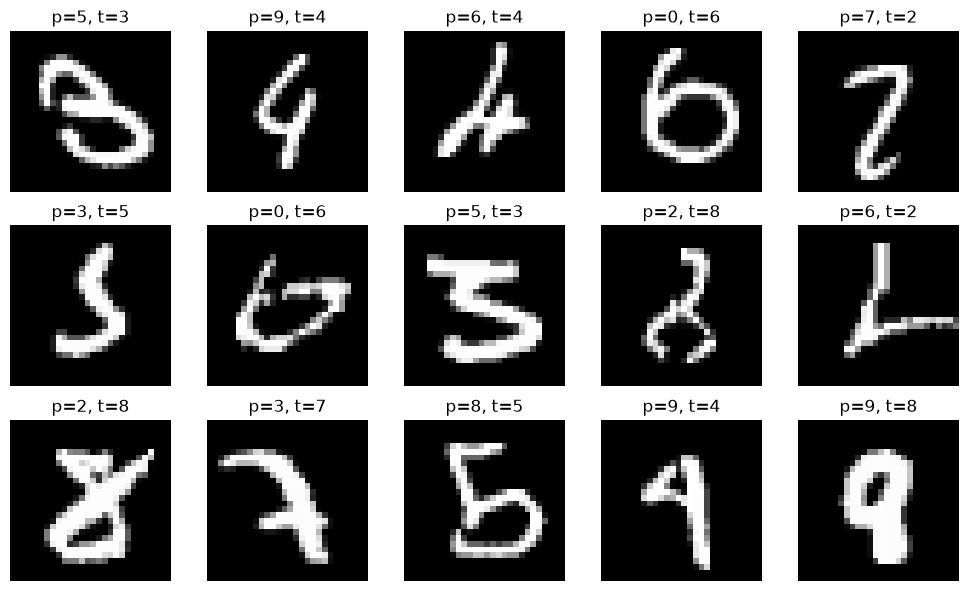

In [16]:
wrong_idx = np.where(all_preds != all_true)[0]
print('total mistakes:', len(wrong_idx))

fig, axes = plt.subplots(3, 5, figsize=(10, 6))
for ax, idx in zip(axes.ravel(), wrong_idx[:15]):
    img, true = test_dataset[idx]
    vis = img.squeeze().numpy() * 0.3081 + 0.1307
    pred = all_preds[idx]
    ax.imshow(vis, cmap='gray')
    ax.set_title(f'p={pred}, t={true}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [17]:
os.makedirs('artifacts', exist_ok=True)
model_path = 'artifacts/mnist_cnn_state_dict.pth'
torch.save(model.state_dict(), model_path)
print('saved to:', model_path)

saved to: artifacts/mnist_cnn_state_dict.pth


In [18]:
loaded_model = MNISTCNN().to(device)
loaded_model.load_state_dict(torch.load(model_path, map_location=device))
loaded_model.eval()

with torch.no_grad():
    sample_logits = loaded_model(X_vis[:8].to(device))
    sample_preds = sample_logits.argmax(dim=1).cpu().numpy()

print('loaded model predictions:', sample_preds)
print('ground truth           :', y_vis[:8].numpy())

loaded model predictions: [7 2 1 0 4 1 4 9]
ground truth           : [7 2 1 0 4 1 4 9]
